## How to read this notebook

| Section | Audience |
|---|---|
| Executive Summary | Non-technical business stakeholder |
| Technical Summary | Data/analytics audience |
| Volatility modeling (GARCH) → Price modeling (ARIMA) → Baseline check | Technical walkthrough |
| Recommendations for Production Use | Anyone deciding whether/how to operationalize this |

## Executive Summary

**What we did:** We looked at Google (GOOG) stock over the past several years to answer two
separate questions: *(1) how jumpy/risky is this stock day to day?* and *(2) can we predict where
the price is headed?*

**What we found:**
- **Risk/volatility is predictable in the short term.** A standard statistical model (GARCH)
  does a reasonable job of anticipating how big tomorrow's price swing is likely to be — even if
  it can't say which direction. This is useful for sizing risk (e.g., how much cushion to hold),
  not for picking winners.
- **Price direction is not reliably predictable.** Once we forecast one day at a time and compare
  honestly against the simplest possible guess — "tomorrow's price will be about the same as
  today's" — our price model does **not** clearly beat that simple guess. This matches decades of
  finance research: short-horizon stock prices behave close to a random walk, and that's a finding
  worth reporting honestly rather than a shortcoming to hide.
- **Bottom line for decision-makers:** this analysis is a solid input for **risk-sizing and
  volatility monitoring**, not a trading signal. Treat any price forecast here as a trend
  visualization for context, not a buy/sell recommendation.

**What we'd need to make this decision-ready:** a named business owner for the resulting action,
an agreed retraining/monitoring cadence, and a business KPI (see *Recommendations for Production
Use* at the end) — not just model accuracy.

## Technical Summary (technical audience)

- **Data:** GOOG daily OHLCV pulled via `yfinance`. Volatility model uses a long window
  (2005–2021) for a stable GARCH fit; price model uses a shorter, more recent window
  (2019–2021) where the trend is cleaner and non-stationarity is easier to reason about.
- **Volatility:** GARCH(1,1) on daily returns, parameter choice supported by PACF of squared
  returns. Evaluated with a walk-forward (rolling, refit-every-step) one-day-ahead backtest
  against realized absolute returns.
- **Price level:** ARIMA(1,1,1), order chosen via ADF stationarity test (d=1) + ACF/PACF of the
  first difference (p=1, q=1). Evaluated two ways: (a) a single multi-step forecast over the full
  test horizon, and (b) a walk-forward one-step-ahead rolling forecast — **these are not
  comparable to each other** (multi-step vs. one-step), so a **naive persistence baseline** is
  added as the fair one-step-ahead comparison.
- **Headline result:** printed in the comparison table near the end of the notebook — compare the
  *rolling ARIMA* row against the *naive baseline* row directly, since both are one-step-ahead.

## Business task:
    Identification of volatility and prediction of stock prices

## Datasource description:

Public daily OHLCV data pulled from Yahoo Finance via the `yfinance` package.

The raw history from `yfinance` contains 7 columns: `Open`, `High`, `Low`, `Close`, `Volume`,
`Dividends`, `Stock Splits`. 

## Environment & configuration

In [1]:
# Import libraries
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA          
from arch import arch_model

register_matplotlib_converters()

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# ---- Configuration ----
TICKER = "GOOG"

# Long window for the GARCH volatility fit (more history -> more stable variance estimate)
VOL_START, VOL_END = "2005-01-01", "2021-10-08"

# Shorter, more recent window for the price/trend (ARIMA) analysis
PRICE_START, PRICE_END = "2019-01-01", "2021-10-08"
TRAIN_END = "2021-07-01"
TEST_END = PRICE_END

GARCH_TEST_OBS = 365 * 3

RANDOM_STATE = 42 

DATA_PULLED_AT = datetime.now().isoformat(timespec="seconds")
print(f"Notebook executed at: {DATA_PULLED_AT}")
print(f"Ticker: {TICKER} | Volatility window: {VOL_START} to {VOL_END} "
      f"| Price window: {PRICE_START} to {PRICE_END}")

Notebook executed at: 2026-08-20T21:16:28
Ticker: GOOG | Volatility window: 2005-01-01 to 2021-10-08 | Price window: 2019-01-01 to 2021-10-08


In [3]:
# ---- Environment info  ----
import sys
import pandas as _pd
import numpy as _np
import matplotlib as _mpl

print("python     :", sys.version.split()[0])
print("pandas     :", _pd.__version__)
print("numpy      :", _np.__version__)
print("matplotlib :", _mpl.__version__)

for _pkg in ["statsmodels", "arch", "yfinance", "pmdarima"]:
    try:
        _mod = __import__(_pkg)
        print(f"{_pkg:11s}:", getattr(_mod, "__version__", "version not exposed"))
    except ImportError:
        print(f"{_pkg:11s}: NOT INSTALLED")


python     : 3.14.7
pandas     : 3.0.5
numpy      : 2.5.2
matplotlib : 3.11.1
statsmodels: 0.14.6
arch       : 8.0.0
yfinance   : 1.6.0
pmdarima   : NOT INSTALLED


In [5]:
results = []  # collects one dict per evaluated forecast, for the summary table near the end

def evaluate_forecast(actual, predicted, label, record=True):
    """Align two series on their shared index and report RMSE / MAE / MAPE.

    MAPE is undefined/unstable when `actual` can be at or near zero (true for daily returns,
    fine for a price level in dollars) -- it's still computed but should be read with that
    caveat for the volatility backtest below.
    """
    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(predicted).astype(float)
    actual, predicted = actual.align(predicted, join="inner")
    resid = actual - predicted

    rmse = float(np.sqrt(np.mean(resid ** 2)))
    mae = float(np.mean(np.abs(resid)))
    mape = float(np.mean(np.abs(resid / actual)))

    print(f"{label:50s} RMSE={rmse:,.4f}  MAE={mae:,.4f}  MAPE={mape:.2%}")

    if record:
        results.append({"model": label, "rmse": rmse, "mae": mae, "mape": mape})
    return {"residuals": resid, "rmse": rmse, "mae": mae, "mape": mape}


def ADF_test(series, label=""):
    """Augmented Dickey-Fuller stationarity test. Returns the stat/p-value in addition to
    printing them, so callers can use the result programmatically instead of just reading it
    off stdout."""
    result = adfuller(pd.Series(series).dropna())
    print(f"ADF test {label + ' ' if label else ''}-> statistic: {result[0]:.4f}, "
          f"p-value: {result[1]:.4f}")
    return {"statistic": result[0], "p_value": result[1]}

FIGSIZE = (10, 4)  

## Getting data:

In [7]:
tickerData = yf.Ticker(TICKER)

# Historical data for the volatility model (long window)
df = tickerData.history(start=VOL_START, end=VOL_END)
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2005-01-03 00:00:00-05:00,4.873603,5.027663,4.825707,5.004702,636143518,0.0,0.0
2005-01-04 00:00:00-05:00,4.972357,5.010131,4.776820,4.802003,552298420,0.0,0.0
2005-01-05 00:00:00-05:00,4.776081,4.861258,4.745961,4.777563,330698912,0.0,0.0
2005-01-06 00:00:00-05:00,4.816324,4.836569,4.634613,4.655105,417041336,0.0,0.0
2005-01-07 00:00:00-05:00,4.706705,4.795833,4.660784,4.785957,387964757,0.0,0.0


## Data modeling: volatility

First step is to check current volatility. We will use difference between two close prices

In [8]:
# % change in price between one day and the next
returns = 100 * df.Close.pct_change().dropna()

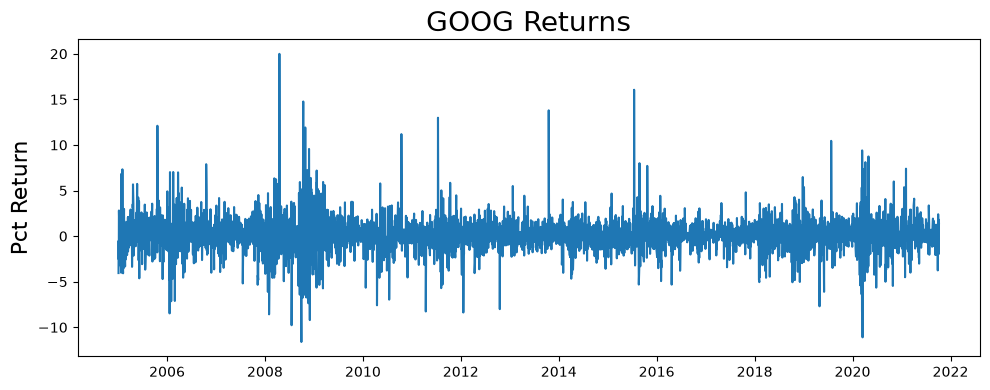

In [9]:
plt.figure(figsize=FIGSIZE)
plt.plot(returns)
plt.ylabel("Pct Return", fontsize=16)
plt.title(f"{TICKER} Returns", fontsize=20)
plt.tight_layout()
plt.show()

As we can see this stock is quite volatile. So, GARCH model can be a good candidate to use for forecast (catch volatility)

In order to find the correct parameters for the model we will use PACF (Partial Auto-correlation function)

### PACF

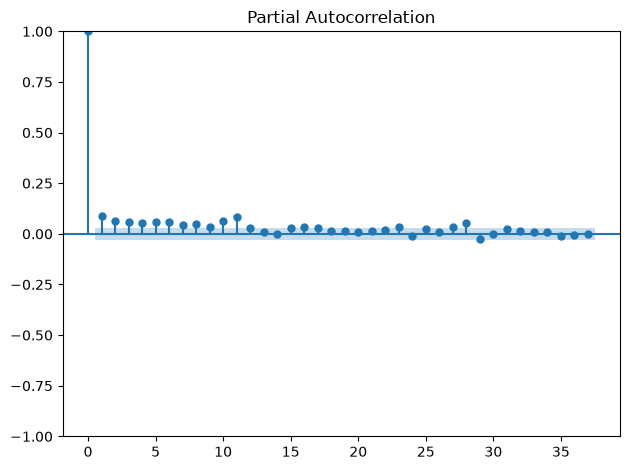

In [10]:
plot_pacf(returns ** 2)
plt.tight_layout()
plt.show()

To not complicate the model, we will use GARCH(1,1). Plus as we can see the value is decreasing on 2, so 1 looks like a good candidate for the model parameter.

### Model build: GARCH(1,1)

In [11]:
garch_model = arch_model(returns, p=1, q=1)
garch_fit = garch_model.fit(disp="off")
garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8243.70
Distribution:                  Normal   AIC:                           16495.4
Method:            Maximum Likelihood   BIC:                           16520.8
                                        No. Observations:                 4220
Date:                Thu, Aug 20 2026   Df Residuals:                     4219
Time:                        21:20:12   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1137  2.557e-02      4.446  8.735e-06 [6.358e-02,  0.164]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1258  7.090e-02      1.774  7.604e-02 [-1.318e-02,  0.265]
alpha[1]       0.0815  3.611e-02      2.258  2.394e-02  [1.076e-02,  0.152]
beta[1]        0.8847  5.011e-02     17.654  9.555e-70    [  0.786,  0.983]
===========================================================================

Covariance estimator: robust
"""

Model looks good: all coefficients are significant.In order to improve the prediction, we will use rolling predictions

### Rolling predictions

In [12]:
def rolling_garch_forecast(returns_series, n_obs, p=1, q=1):
    preds = []
    for i in range(n_obs):
        train = returns_series[: -(n_obs - i)]
        m = arch_model(train, p=p, q=q)
        m_fit = m.fit(disp="off")
        pred = m_fit.forecast(horizon=1)
        preds.append(np.sqrt(pred.variance.values[-1, :][0]))
    return pd.Series(preds, index=returns_series.index[-n_obs:])

vol_rolling_predictions = rolling_garch_forecast(returns, GARCH_TEST_OBS)

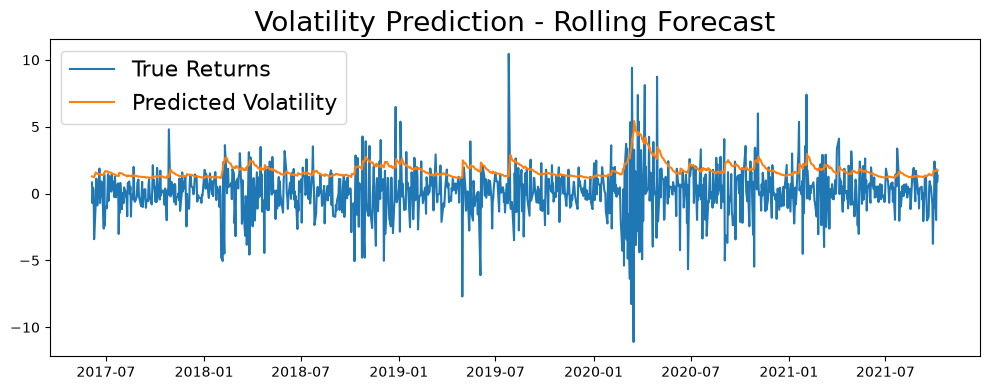

In [13]:
plt.figure(figsize=FIGSIZE)
plt.plot(returns[-GARCH_TEST_OBS:])
plt.plot(vol_rolling_predictions)
plt.title("Volatility Prediction - Rolling Forecast", fontsize=20)
plt.legend(["True Returns", "Predicted Volatility"], fontsize=16)
plt.tight_layout()
plt.show()

We were able to catch the volatility of the stock.

**Quantitative check**. 
We compare the rolling *predicted* volatility against a simple realized-volatility proxy (absolute daily
returns) over the same window. Read RMSE/MAE here, not MAPE — MAPE divides by the actual value,
and daily returns can sit at or near zero, which makes that ratio unstable/misleading for this
particular series.

In [14]:
realized_vol_proxy = returns[-GARCH_TEST_OBS:].abs()
_ = evaluate_forecast(realized_vol_proxy, vol_rolling_predictions,
                       "GARCH(1,1) rolling volatility forecast")

GARCH(1,1) rolling volatility forecast             RMSE=1.3315  MAE=1.0557  MAPE=725.05%


## Data modeling: stock price forecast

Before we move to stock price forecast, it is worth to do a time series analysis

In [15]:
# Historical data for the price model
ddf = tickerData.history(start=PRICE_START, end=PRICE_END)

In [16]:
inferred_freq = pd.infer_freq(ddf.index)
ddf = ddf.asfreq(inferred_freq or "B")

In [17]:
ddf["Open"] = ddf["Open"].ffill().bfill()

In [18]:
prices = ddf.Open

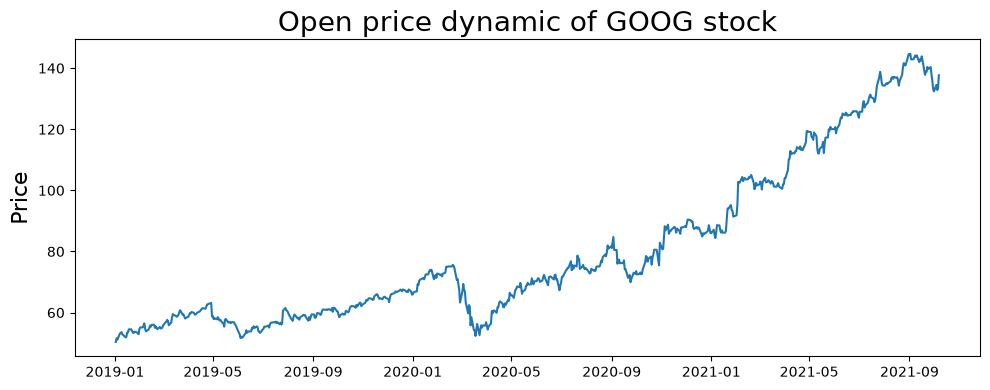

In [19]:
plt.figure(figsize=FIGSIZE)
plt.plot(prices)
plt.title(f"Open price dynamic of {TICKER} stock", fontsize=20)
plt.ylabel("Price", fontsize=16)
plt.tight_layout()
plt.show()

We can clearly see the trend. In this case, ARIMA can be a good candidate for stock price modeling

Let's check stationarity. For this we will use Augmented Dickey–Fuller test

### Stationarity

In [20]:
_ = ADF_test(prices, "price level")

ADF test price level -> statistic: 0.5832, p-value: 0.9872


Obviously the time-series is not stationary.

To dive deeper, we will do a decomposition

### Decomposition

In [21]:
stl = STL(prices)
result = stl.fit()

In [22]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid

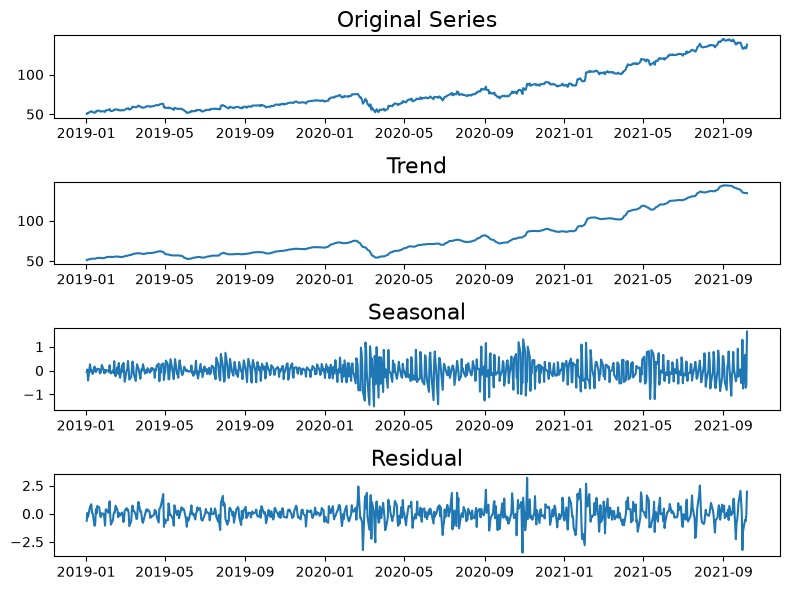

In [23]:
plt.figure(figsize=(8, 6))

plt.subplot(4, 1, 1)
plt.plot(prices)
plt.title("Original Series", fontsize=16)

plt.subplot(4, 1, 2)
plt.plot(trend)
plt.title("Trend", fontsize=16)

plt.subplot(4, 1, 3)
plt.plot(seasonal)
plt.title("Seasonal", fontsize=16)

plt.subplot(4, 1, 4)
plt.plot(resid)
plt.title("Residual", fontsize=16)

plt.tight_layout()
plt.show()

No seasonality, what is logical, but we can clearly see trend.

So, we can conclude that ARIMA model should work in our case. In order to find parameters for the model, we will check the first difference on stationarity and perform a ACF and PACF

### Work with first difference

In [24]:
first_diff = prices.diff().dropna()

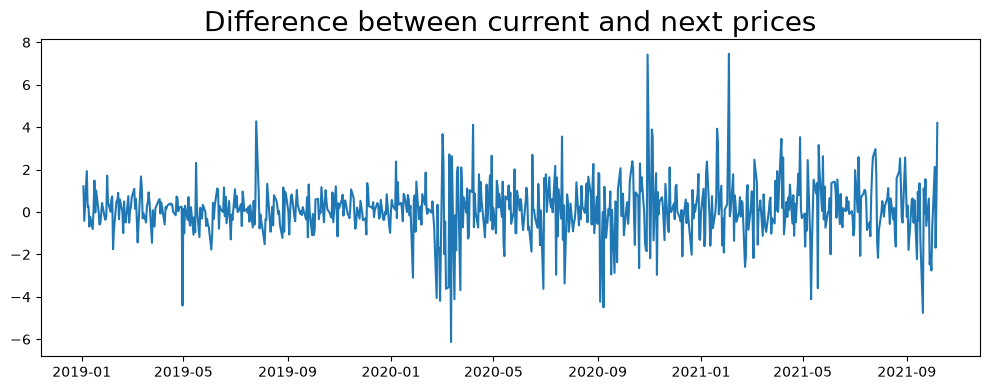

In [25]:
plt.figure(figsize=FIGSIZE)
plt.plot(first_diff)
plt.title("Difference between current and next prices", fontsize=20)
plt.tight_layout()
plt.show()

In [26]:
_ = ADF_test(first_diff, "first difference")

ADF test first difference -> statistic: -27.6798, p-value: 0.0000


Test showed that time series is stationary. Hence, d=1. One parameter is defined.

### Building a Auto-correlation function

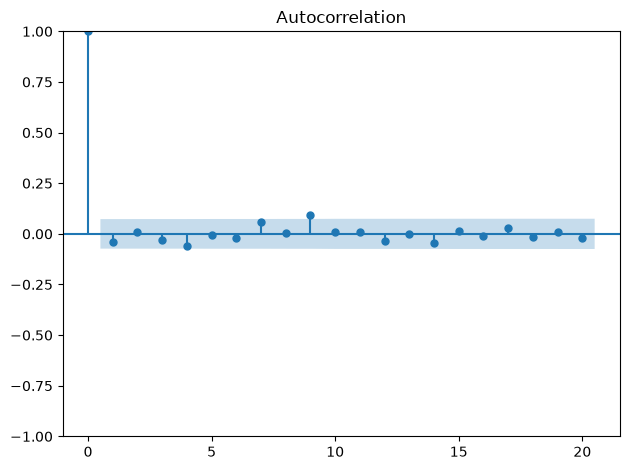

In [27]:
plot_acf(first_diff, lags=20)
plt.tight_layout()
plt.show()

1 looks like a good candidate => MA(1)

### Building a Partial Auto-correlation function

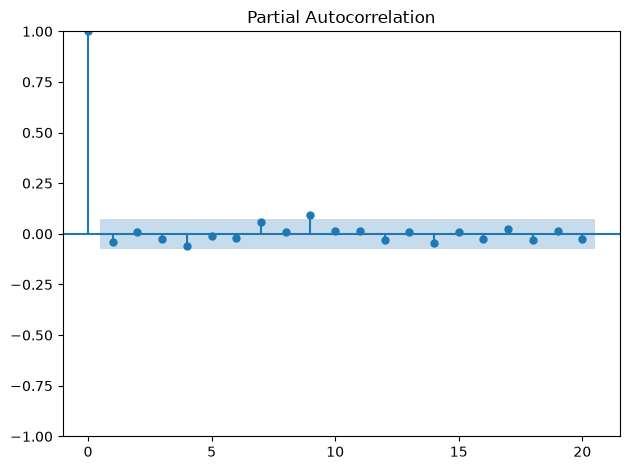

In [28]:
plot_pacf(first_diff, lags=20)
plt.tight_layout()
plt.show()

1 looks like a good candidate => AR(1)

### ARIMA Model (1,1,1)

In [31]:
train_data = prices[:TRAIN_END]
test_data = prices[(pd.Timestamp(TRAIN_END) + timedelta(days=1)).tz_localize(prices.index.tz):pd.Timestamp(TEST_END).tz_localize(prices.index.tz)]

In [32]:
arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Open   No. Observations:                  652
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1097.841
Date:                Thu, 20 Aug 2026   AIC                           2201.682
Time:                        21:25:49   BIC                           2215.118
Sample:                    01-02-2019   HQIC                          2206.893
                         - 07-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2619      0.405     -0.647      0.518      -1.056       0.532
ma.L1          0.1981      0.409      0.484      0.628      -0.604       1.000
sigma2         1.7073      0.051     33.347      0.0

In [33]:
forecast_result = arima_fit.get_forecast(steps=len(test_data))
predictions = forecast_result.predicted_mean
predictions.index = test_data.index
conf_int = forecast_result.conf_int()
conf_int.index = test_data.index

In [34]:
residuals = test_data - predictions

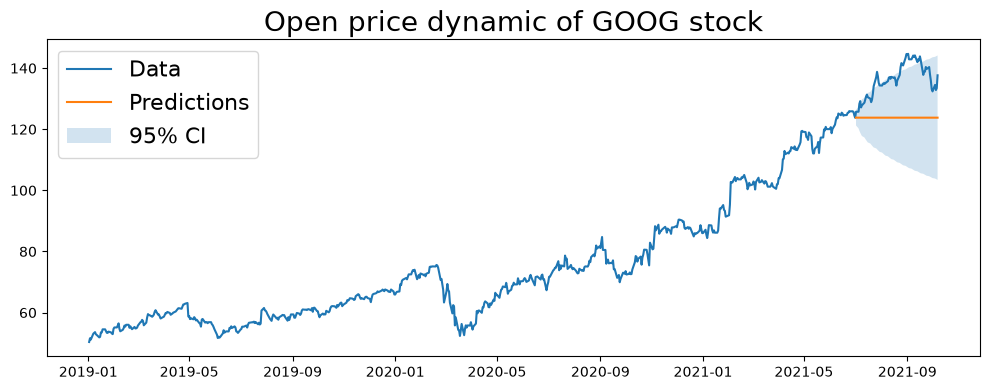

In [35]:
plt.figure(figsize=FIGSIZE)
plt.plot(prices, label="Data")
plt.plot(predictions, label="Predictions")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  alpha=0.2, label="95% CI")
plt.legend(fontsize=16)
plt.title(f"Open price dynamic of {TICKER} stock", fontsize=20)
plt.tight_layout()
plt.show()

### Model quality check

In [36]:
_ = evaluate_forecast(test_data, predictions,
                       "ARIMA(1,1,1) - single multi-step forecast")

ARIMA(1,1,1) - single multi-step forecast          RMSE=13.7431  MAE=12.7367  MAPE=9.20%


Overall, we caught the trend, but still it is a bit far from the true prices. As noted above, this is expected for a ~99-day-ahead compounding forecast rather than a flaw specific to this model choice.

### Rolling forecast

In [37]:
def rolling_arima_forecast(price_series, test_index, order=(1, 1, 1)):
    preds = price_series.reindex(test_index).astype(float).copy()
    for t in test_index:
        train = price_series[: t - timedelta(days=1)]
        m = ARIMA(train, order=order)
        m_fit = m.fit()
        preds[t] = m_fit.forecast(steps=1).iloc[0]
    return preds

price_rolling_predictions = rolling_arima_forecast(prices, test_data.index)

In [38]:
rolling_residuals = test_data - price_rolling_predictions

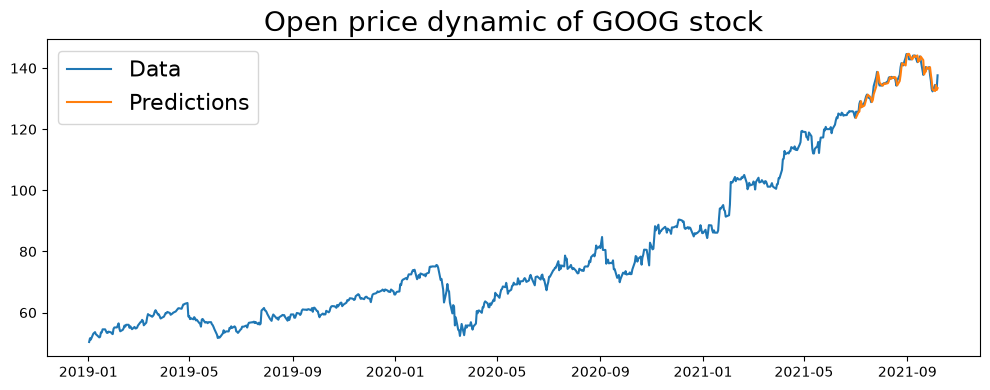

In [39]:
plt.figure(figsize=FIGSIZE)
plt.plot(prices, label="Data")
plt.plot(price_rolling_predictions, label="Predictions")
plt.legend(fontsize=16)
plt.title(f"Open price dynamic of {TICKER} stock", fontsize=20)
plt.tight_layout()
plt.show()

### Model quality check

In [40]:
_ = evaluate_forecast(test_data, price_rolling_predictions,
                       "ARIMA(1,1,1) - rolling one-step forecast")

ARIMA(1,1,1) - rolling one-step forecast           RMSE=1.5519  MAE=1.2103  MAPE=0.89%


We can see that with rolling forecast we were able to achieve better results: now we can catch changes in price. It is also clear if we look at error indicators: they decreased significantly compared to the multi-step forecast above.

In [41]:
naive_predictions = prices.shift(1).reindex(test_data.index)
_ = evaluate_forecast(test_data, naive_predictions,
                       "Naive persistence baseline (1-day)")

Naive persistence baseline (1-day)                 RMSE=1.5397  MAE=1.2047  MAPE=0.88%


### Comparison table

In [42]:
comparison_df = pd.DataFrame(results).set_index("model")
comparison_df

,rmse,mae,mape
model,,,
"GARCH(1,1) rolling volatility forecast",1.331504,1.055659,7.250528
"ARIMA(1,1,1) - single multi-step forecast",13.743056,12.736665,0.091982
"ARIMA(1,1,1) - rolling one-step forecast",1.551894,1.210272,0.008893
Naive persistence baseline (1-day),1.539652,1.204705,0.008850


The rolling ARIMA forecast (RMSE 1.552, MAPE 0.889%) does **not** beat
the naive persistence baseline (RMSE 1.540, MAPE 0.885%) — it's marginally worse on every metric.
This means ARIMA(1,1,1) is not demonstrating predictive edge over "assume tomorrow's price equals
today's" for this one-step-ahead task. That's consistent with the efficient-market/random-walk
result for short-horizon equity prices, and it's the reason this baseline was added: without it,
the rolling forecast's low error would look like a success on its own, when in fact it's just
tracking how little day-to-day prices move.

The single multi-step forecast (RMSE 13.74, MAPE 9.20%) is far worse than either one-step
approach, but isn't a fair comparison to them (99-day compounding forecast vs. one-day-ahead).

The GARCH(1,1) volatility row (RMSE 1.33) answers a different question — the *size* of tomorrow's
move, not its price level or direction — and isn't directly comparable to the price rows above it.

**Bottom line:** this analysis does not support using ARIMA(1,1,1) price forecasts as a trading
signal. The volatility (GARCH) forecast, evaluated separately against realized volatility, is the
better-supported use case for this data.

In [43]:
avg_price = prices.mean()
avg_daily_move_dollars = prices.diff().abs().mean()
rolling_row = comparison_df.loc["ARIMA(1,1,1) - rolling one-step forecast"]
naive_row = comparison_df.loc["Naive persistence baseline (1-day)"]

print(f"Average {TICKER} price over the analysis window: ${avg_price:,.2f}")
print(f"Average day-to-day price move (typical daily swing): ${avg_daily_move_dollars:,.2f}")
print(f"Rolling ARIMA one-step RMSE: ${rolling_row['rmse']:,.2f} "
      f"({rolling_row['rmse'] / avg_price:.2%} of average price)")
print(f"Naive baseline one-step RMSE: ${naive_row['rmse']:,.2f} "
      f"({naive_row['rmse'] / avg_price:.2%} of average price)")
print(f"ARIMA's edge over naive: ${naive_row['rmse'] - rolling_row['rmse']:,.2f} "
      "(negative means ARIMA is worse than doing nothing)")

Average GOOG price over the analysis window: $80.50
Average day-to-day price move (typical daily swing): $0.92
Rolling ARIMA one-step RMSE: $1.55 (1.93% of average price)
Naive baseline one-step RMSE: $1.54 (1.91% of average price)
ARIMA's edge over naive: $-0.01 (negative means ARIMA is worse than doing nothing)


**External benchmark:** rather than invent a target accuracy figure, the defensible external
benchmark here is the naive/persistence forecast itself — a standard, well-established baseline
in financial forecasting precisely because of the efficient-market/random-walk result: if a model
can't beat "no change," it has no demonstrated forecasting edge, regardless of how good its RMSE
looks in isolation. The same logic is why professional volatility desks benchmark a GARCH-type
forecast against realized volatility (as done above) rather than judging it against an arbitrary
target number.

### Operationalization

| Question | Answer for this analysis |
|---|---|
| **Who consumes this output?** | Volatility forecast (GARCH): risk/trading desk, for position sizing and stop-loss/hedge calibration. Price forecast (ARIMA): at most a contextual trend view for stakeholders — not recommended as a standalone signal given the baseline comparison above. |
| **How often is it retrained?** | Proposed: nightly refit for the production one-step-ahead forecast, mirroring the rolling backtest already built in this notebook; weekly review of aggregate error trend. This is a proposal to validate with the consuming team, not a claim that it's already running this way. |
| **How is drift monitored?** | Track rolling RMSE/MAE (the same `evaluate_forecast` function used throughout this notebook) over a trailing production window; alert if error rises materially above the backtest baseline established here. Periodically re-run the ADF stationarity check, since the ARIMA order (1,1,1) was chosen based on stationarity properties that can change over time (regime shifts, splits, etc.). |
| **Who owns the model vs. who owns the resulting action?** | *Model owner* (this analysis's author / data science team): model correctness, retraining, drift monitoring, this documentation. *Action owner* (risk/trading desk lead): decides what to actually do with a given forecast — e.g., adjust hedge size — and is accountable for that decision's outcome. These should be two different named people, not the same person wearing both hats. |
| **What's the actual success metric?** | Not a model metric (RMSE/MAPE are diagnostic, not the business goal). Candidate business KPIs to validate with the business owner: reduction in unhedged overnight exposure, hedging cost avoided, or Sharpe ratio of a volatility-sized strategy vs. a static-volatility baseline. These are **illustrative candidates**, not measured results — the business owner should confirm which KPI actually matters before this ships. |

### Limitations & honest caveats

- Single ticker, univariate models — no macro, sector, or fundamental features; no news/sentiment.
- GARCH forecasts the *magnitude* of tomorrow's move, not its *direction* — not a trading signal
  by itself.
- ARIMA's rolling one-step forecast should be read alongside the naive baseline above, not in
  isolation.
- No transaction costs, slippage, or execution constraints are modeled — none of this is a backtested
  trading strategy.
- This notebook is analysis, not investment advice.